# Downsampling approaches
Exploring & implementing the different approaches to downsampling a genome

## MinHashing
Confirmed downsampling approach from Special Course.

Pros:
- Fast & efficient

Cons:
- Hashing algorithm unavailable; backtracking hash values to kmers is not possible (e.g. feature attributions for NNs)

### Constructing singular signatures

In [17]:
import os, sys 
from manipulations import construct_SM_sketches
from io_operations import presence_matrix
from paths import raw_data_path, data_prod_path

### Phage Minhash Sketch Construction ###
pk = 12
pn = 0
ps = 1
phage_outdir = f"TEST_PhageMinhash_n{pn}_k{pk}/"
construct_SM_sketches(raw_in = raw_data_path+"phagehost_KU/phage_cleaned.fasta", 
                      k = pk, 
                      outdir = phage_outdir, 
                      parent_outdir= "TEST_SM_sketches/",
                      quiet = False,
                      sourmash_parameters=[pn, ps])

### Bacteria Minhash Sketch Construction ###
# bk = 12
# bn = 500
# bact_outdir = f"TEST_BactMinhash_n{bn}_k{bk}/"
# construct_SM_sketches(raw_in = raw_data_path+"phagehost_KU/bacteria_fasta/", 
#                       k = bk, 
#                       outdir = bact_outdir, 
#                       parent_outdir= "TEST_SM_sketches/",
#                       quiet = False,
#                       sourmash_parameters=[bn, 0])


Created output directory: TEST_PhageMinhash_n0_k12/
Output path for sketches: /net/node07/home/projects/s215045/PredictPhagePPI/data_prod/TEST_SM_sketches/TEST_PhageMinhash_n0_k12/
------- Constructing MinHashes -------


Constructing minhashes for all records: 100%|██████████| 23/23 [00:04<00:00,  5.15seq/s]


------- Saving Sketches -------
------- Process Completed -------


In [ ]:
from pickle import dump
### Presence Matrix
presence_outdir = f"SM_sketches/PresMat_bn{bn}_bk{bk}_pn{pn}_pk{pk}/"
try:
    os.makedirs(data_prod_path+presence_outdir)
except FileExistsError: # directory already exists
    pass

try:
    binary_matrix, entity_to_index, minhash_to_index, phage_minhash_data, bact_minhash_data = presence_matrix(
        phage_minhash_dir=data_prod_path+"SM_sketches/"+phage_outdir, 
        bact_minhash_dir=data_prod_path+"SM_sketches/"+bact_outdir,
        k=[bk, pk],
        n=[bn, pn],
        reversecomp_data=False, TS=True)
except Exception as e:
    raise RuntimeError(f"Failed to run presence_matrix succesfully, exception: {e}")

try:
    with open(data_prod_path+presence_outdir+"binary_matrix.pkl", "wb") as binary_matrix_file:
        dump(binary_matrix, binary_matrix_file)
    with open(data_prod_path+presence_outdir+"entity_to_index.pkl", "wb") as entity_to_index_file:
        dump(entity_to_index, entity_to_index_file)
    with open(data_prod_path+presence_outdir+"minhash_to_index.pkl", "wb") as minhash_to_index_file:
        dump(minhash_to_index, minhash_to_index_file)
    with open(data_prod_path+presence_outdir+"phage_minhash_data.pkl", "wb") as phage_minhash_data_file:
        dump(phage_minhash_data, phage_minhash_data_file)
    with open(data_prod_path+presence_outdir+"bact_minhash_data.pkl", "wb") as bact_minhash_data_file:
        dump(bact_minhash_data, bact_minhash_data_file)
except Exception as e:
    print(f"Failed to save presence_matrix results to {presence_outdir}:\n{e}")

### Constructing multiple signatures

In [ ]:
from manipulations import construct_SM_sketches
import os, sys 
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"

for k in [6, 9, 12, 15, 18, 24]:
    for n in [50, 100, 500, 1000, 5000]:
        #Phages minhash sketches
        construct_SM_sketches(fasta = raw_data_path+"phagehost_KU/phage_cleaned.fasta", 
                            k = k, 
                            outdir = f"PhageMinhash_n{n}_k{k}_rev/", 
                            quiet = False,
                            sourmash_parameters=[n, 0],
                            include_reverse=True)
        
        #Bacteria minhash sketches
        construct_SM_sketches(fasta = raw_data_path+"phagehost_KU/bacteriaKU_cleaned.fasta", 
                        k = k, 
                        outdir = f"BactMinhash_n{n}_k{k}_rev/", 
                        quiet = False,
                        sourmash_parameters=[n, 0],
                        include_reverse=True)

### Behind the curtains 
for constructing the functions construct_SM_sketches

In [ ]:
import sourmash
import pandas as pd
from Bio import SeqIO
import os, sys
from tqdm import tqdm
import numpy as np

def construct_SM_sketches_dev(raw_in : str, k : int, outdir : str, quiet : bool = False, sourmash_parameters = [50000, 0], include_reverse : bool = False) -> int:
    """
    Construct sourmash sketches given a fasta input.
    
    Args:
        *raw_in* (str): Path to the input fasta file or directory containing fasta files.
        *k* (int): Length of the k-mers. 
        *outdir* (str): directory for storing sketches (each signature in its own file)
        *quiet* (bool): If True, suppress progress output. Default is False.
        *sourmash_parameters* (list): specify sourmash.MinHash(n, scaled)
        *include_reverse* (bool): include the reverse strand to sketches
    
    Returns:
        *exit_status* (binary): 0 for success, 1 for failure.
    """
    import sourmash

    ### Input Control ###
    if type(outdir) is not str:
        raise ValueError("outdir must be a path")
    
    if not os.path.exists(data_prod_path+"SM_sketches/"):
        try:
            os.makedirs(data_prod_path+"SM_sketches/", exist_ok=True)
            if not quiet: print(f"Created output directory: {data_prod_path}SM_sketches/")
        except OSError as e:
            raise ValueError(f"Could not create outdir {data_prod_path}SM_sketches/: {e}")
    
    # Ensure outdir exists (create if missing)
    if not os.path.exists(data_prod_path+"SM_sketches/"+outdir):
        try:
            os.makedirs(data_prod_path+"SM_sketches/"+outdir, exist_ok=True)
            if not quiet: print(f"Created output directory: {outdir}")
        except OSError as e:
            raise ValueError(f"Could not create outdir {outdir}: {e}")
    elif not os.path.isdir(data_prod_path+"SM_sketches/"+outdir):
        raise ValueError(f"outdir exists but is not a directory: {outdir}")

    outpath = data_prod_path+"SM_sketches/"+outdir
    if not quiet: print(f"Output path for sketches: {outpath}")

    # Ensuring sourmash parameters are appropriate
    if sourmash_parameters[0] > 0 and sourmash_parameters[1] > 0:
        raise ValueError("One of the sourmash parameters should be 0")

    for p in sourmash_parameters:
        if type(p) is not int:
            raise ValueError("sourmash parameters must be both integers")

    # Handling both cases of fasta input
    raw_is_dir = os.path.isdir(raw_in)

    if raw_is_dir:  # If a directory path is provided, read all fasta files in the directory
        try:
            records = []
            rec_names = []
            for file in os.listdir(raw_in):
                rec_names.append(file.split("_reoriented.fna")[0])
                if file.endswith(".fasta") or file.endswith(".fna"):
                    records_inner = []
                    for rec in SeqIO.parse(os.path.join(raw_in, file), "fasta"):
                        records_inner.append(rec)
                    records.append(records_inner)
        except FileNotFoundError as e:
            print(f"Error: {e}. Please check the file path.")
            return 1
    else:
        try:
            records = list(SeqIO.parse(raw_in, "fasta"))
        except FileNotFoundError as e:
            print(f"Error: {e}. Please check the file path.")
            return 1

    ### Constructing minhashes for all records ###
    if not quiet: print("------- Constructing MinHashes -------")
    minhashes = []
    for rec in tqdm(records, desc="Constructing minhashes for all records", unit="seq"):
        if raw_is_dir:
            try:
                mh = sourmash.MinHash(n=sourmash_parameters[0], ksize=k, scaled=sourmash_parameters[1]) #each record gets its own minhash | scaled=1000 to limit memory usage
                for rec_inner in rec:
                    for i in range(0, len(rec_inner.seq) - k + 1):
                        kmer = str(rec_inner.seq[i:i+k])
                        mh.add_sequence(kmer, force=True)
                        if include_reverse:
                            mh.add_sequence(kmer[::-1], force=True)
                minhashes.append(mh)
            except:
                raise SystemError("Error in constructing minhashes")
        else:
            try:
                mh = sourmash.MinHash(n=sourmash_parameters[0], ksize=k, scaled=sourmash_parameters[1]) #each record gets its own minhash | scaled=1000 to limit memory usage
                for i in range(0, len(rec.seq) - k + 1):
                    kmer = str(rec.seq[i:i+k])
                    mh.add_sequence(kmer, force=True)
                    if include_reverse:
                        mh.add_sequence(kmer[::-1], force=True)
                minhashes.append(mh)
            except:
                raise SystemError("Error in constructing minhashes")

    ### Saving sketches ###
    if not quiet: print("------- Saving Sketches -------")
    if "bact" in raw_in:
        outfile_prefix = "bact"
    elif "phage" in raw_in:
        outfile_prefix = "phage"
    else:
        outfile_prefix = "out"

    for i in range(len(minhashes)):
        try:
            with open(outpath+f"{outfile_prefix}{i}_minhash.sig", "wt") as sigfile:
                if raw_is_dir:
                    sig1 = sourmash.SourmashSignature(minhashes[i], name=rec_names[i])
                else:
                    sig1 = sourmash.SourmashSignature(minhashes[i], name=records[i].id)
                sourmash.save_signatures([sig1], sigfile)
        except:
            raise SystemError(f"Error in saving sourmash sketch for: {records[i].id}")
    print("------- Process Completed -------")

In [ ]:
import os, sys 
from io_operations import presence_matrix
from paths import raw_data_path, data_prod_path

### Phage Minhash Sketch Construction ###
pk = 12
pn = 500
phage_outdir = f"PhageMinhash_n{pn}_k{pk}/"
construct_SM_sketches_dev(raw_in = raw_data_path+"phagehost_KU/phage_cleaned.fasta", 
                      k = pk, 
                      outdir = phage_outdir, 
                      quiet = False,
                      sourmash_parameters=[pn, 0])

### Bacteria Minhash Sketch Construction ###
bk = 12
bn = 500
bact_outdir = f"BactMinhash_n{bn}_k{bk}/"
construct_SM_sketches_dev(raw_in = raw_data_path+"phagehost_KU/bacteria_fasta/", 
                      k = bk, 
                      outdir = bact_outdir, 
                      quiet = False,
                      sourmash_parameters=[bn, 0])

## Novel decompisition method
Develop a new method, where i can backtrack the decomposed integers, to its original kmer sequences

Encoder Process:
1) encode the forward k-mer to bit-level integer
2) encode its reverse complement 
3) keep only the smaller of the two

Decomposition Process:
1) divide genome into kmer of size k
2) keep only every x entry, where x = n/genome_kmer_size (n = sig size)
3) save to disk

### Encoder

In [1]:
from decompositions import KmerCodec
codec = KmerCodec()
my_kmer = "ATC"
k_size = len(my_kmer)

# 1. Decompose to integer
encoded_val = codec.encode_with_revcomp(my_kmer)
print(f"Original: {my_kmer}")
print(f"Integer representation: {encoded_val}") # 8864 in decimal

# 2. Backtrack to sequence
decoded_val = codec.decode(encoded_val, k_size)
print(f"Backtracked: {decoded_val}")

Original: ATC
Integer representation: 386
Backtracked: ATC


### Decomposition

In [2]:
from decompositions import Decompose
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"

k = 12
n = 500
hash_func = "mmh3"

# The 'with' block handles the creation and deletion of tmp automatically
with Decompose(k=k, n=n, codec=codec, output_dir=data_prod_path+"TEST_encoded_sketches/", entity_type="phage", sourmash_like=True, 
               custom_dir_name=f"Phagemmh3_n{n}_k{k}", hash_func=hash_func, sample_all=True) as decomposer:
    decomposer.decompose(raw_data_path+"phagehost_KU/phage_cleaned.fasta")

with Decompose(k=k, n=n, codec=codec, output_dir=data_prod_path+"TEST_encoded_sketches/", entity_type="bact", sourmash_like=True,
               custom_dir_name=f"Bactmmh3_n{n}_k{k}", hash_func=hash_func) as decomposer:
    decomposer.decompose(raw_data_path+"phagehost_KU/concatenated_bacteria/")

Using custom directory name: ../data_prod/TEST_encoded_sketches/Phagemmh3_n500_k12
Initialized Decompose with k=12, n=None, entity_type='phage', sourmash_like=True
Input path '../raw_data/phagehost_KU/phage_cleaned.fasta' is a directory: False
Processing with sourmash-like output format. Output will be saved in '../data_prod/TEST_encoded_sketches/Phagemmh3_n500_k12'
Processing single FASTA file for phage decomposition.


Processing phage FASTA: 23rec [00:06,  3.81rec/s]


Sourmash-like decomposition completed successfully. Signatures saved in '../data_prod/TEST_encoded_sketches/Phagemmh3_n500_k12'.

Using custom directory name: ../data_prod/TEST_encoded_sketches/Bactmmh3_n500_k12
Initialized Decompose with k=12, n=500, entity_type='bact', sourmash_like=True
Input path '../raw_data/phagehost_KU/concatenated_bacteria/' is a directory: True
Processing with sourmash-like output format. Output will be saved in '../data_prod/TEST_encoded_sketches/Bactmmh3_n500_k12'
Processing directory of FASTA files for bact decomposition.


Processing bact FASTA files: 100%|██████████| 110/110 [03:36<00:00,  1.97s/file]


Sourmash-like decomposition completed successfully. Signatures saved in '../data_prod/TEST_encoded_sketches/Bactmmh3_n500_k12'.



### Checking how expensive it would be to not downsample phages at all

In [ ]:
from Bio import SeqIO
import pandas as pd
n = 500

raw_data_path+"phagehost_KU/phage_cleaned.fasta"
record_info_df2 = pd.DataFrame()

records = list(SeqIO.parse(raw_data_path+"phagehost_KU/phage_cleaned.fasta", "fasta"))
print(f"Total records in phage fasta data1: {len(records)}")

record_info_df = pd.DataFrame({
    "ID": [record.id for record in records],
    "Length": [len(record.seq) for record in records]
})

# # add data2 records to the dataframe
# records2 = list(SeqIO.parse(raw_data_path+"phagehost_KU/data2_phages.fasta", "fasta"))
# print(f"Total records in phage fasta data2: {len(records2)}")

# record_info_df2 = pd.DataFrame({
#     "ID": [record.id for record in records2],
#     "Length": [len(record.seq) for record in records2]
# })

combined_df = pd.concat([record_info_df, record_info_df2], ignore_index=True)
combined_df[f"fraction_in_{n}"] = combined_df["Length"].apply(lambda x: n/x)

# construct a count column with all 

combined_df = combined_df.sort_values(by="Length", ascending=False).reset_index(drop=True)
display(combined_df)

Total records in phage fasta data1: 23


,ID,Length,fraction_in_500
0,Lelliottia_phage_Pantea,150009,0.003333
1,Pectobacterium_phage_Magnum,94385,0.005297
2,Morganella_phage_Rup,60952,0.008203
3,Serratia_phage_Echoes,59690,0.008377
4,Morganella_phage_Rip,59319,0.008429
5,Lelliottia_phage_Zann,51744,0.009663
6,Pectobacterium_phage_Vims,47310,0.010569
7,Pectobacterium_phage_Hoejben,45692,0.010943
8,Pectobacterium_phage_Crus,45644,0.010954
9,Pectobacterium_phage_Gander,45139,0.011077


In [19]:
from io_operations import load_minhash_sketches

#phage_sketches = load_minhash_sketches(data_prod_path+"TEST_encoded_sketches/Phagemmh3_n500_k12/")
phage_sketches = load_minhash_sketches(data_prod_path+"TEST_SM_sketches/TEST_PhageMinhash_n0_k12/")
print(len(phage_sketches["Lelliottia_phage_Pantea"]))

#append phage_sketches data to the dataframe
combined_df["Sketch_Size"] = combined_df["ID"].apply(lambda x: len(phage_sketches[x]) if x in phage_sketches else None)
combined_df["Length_vs_SketchSize"] = combined_df.apply(lambda row: row["Length"] - row["Sketch_Size"] if row["Sketch_Size"] is not None else None, axis=1)
display(combined_df)

145070


,ID,Length,fraction_in_500,Sketch_Size,Length_vs_SketchSize
0,Lelliottia_phage_Pantea,150009,0.003333,145070,4939
1,Pectobacterium_phage_Magnum,94385,0.005297,90672,3713
2,Morganella_phage_Rup,60952,0.008203,60278,674
3,Serratia_phage_Echoes,59690,0.008377,58571,1119
4,Morganella_phage_Rip,59319,0.008429,58607,712
5,Lelliottia_phage_Zann,51744,0.009663,50015,1729
6,Pectobacterium_phage_Vims,47310,0.010569,45255,2055
7,Pectobacterium_phage_Hoejben,45692,0.010943,43827,1865
8,Pectobacterium_phage_Crus,45644,0.010954,43737,1907
9,Pectobacterium_phage_Gander,45139,0.011077,43262,1877


# Statistical Eval on down-sampled signatures

# Fixing Load Encoded Sketch error 29-april

In [ ]:
from paths import data_prod_path
import os, sys
import logging
def load_minhash_sketches(in_dir : str, TS : bool = False, output_as_np : bool = False):
    """
    Load Sourmash Minhash sketches from a directory and concatenate them in a dictionary.

    Args:
        **in_dir** (str): Path to signatures
        **TS** (bool): Troubleshoot on or off
        **output_as_np** (bool): Output minhash vector (values in dict) as np.array rather than the default python list
    
    Returns:
        Dictionary of minhashes, with (extended) phage names / bacteria names as keys and it's minhash composition as a vector [list / np.array]
    
    """
    from sourmash import load_file_as_signatures
    minhash_data = {}
    for filename in os.listdir(in_dir):
        if filename.endswith(('.sig', '.json')): # sourmash signature files
            filepath = os.path.join(in_dir, filename)
            if TS: logging.info(f"filepath: {filepath}")
            try:
                # sourmash.load_signatures returns an iterator
                sig = load_file_as_signatures(filepath)
                
                if not sig:
                    logging.warning(f"No signatures found in {filename}. Skipping.")
                    continue
                
                name = str(sig)
                if output_as_np:
                    hashes = np.array(sorted(sig.minhash.hashes.keys()))
                else:
                    hashes = sorted(sig.minhash.hashes.keys())
                minhash_data[name] = hashes

            except Exception as e:
                logging.error(f"Error loading sketch file {filename}: {e}. Skipping.")

    return minhash_data

sketch = load_minhash_sketches(data_prod_path+"encoded_sketches/bact_sig_n500_k12/", TS=True)

# Investigating Sourmash vs OHE result difference

In [ ]:
import os, sys
import pandas as pd
from paths import data_prod_path

In [ ]:
ohe_example_dir = data_prod_path+"encoded_sketches/bact_sig_n500_k12/"
sourmash_example_dir = data_prod_path+"SM_sketches/BactMinhash_n500_k12/"

for file in os.listdir(ohe_example_dir):
    if not file.endswith('.sig'):
        continue
    with open(os.path.join(ohe_example_dir, file), 'r') as f:
        for line in f:
            print(line, end="")


In [ ]:
for file in os.listdir(sourmash_example_dir):
    if not file.endswith('.sig'):
        continue
    with open(os.path.join(sourmash_example_dir, file), 'r') as f:
        for line in f:
            print(line.replace(",", "\n"), end="")

## Investigating _KMC suffix in cleaned bacteria names

In [1]:
from manipulations import clean_bact_names
clean_bact_names(["J2264_1_22_KMC_reoriented"])

['J2264_1']

# Investigating distance used in dendrogram plot

In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt
X = [[i] for i in [0.8, 0.3, 0.2, 0.1, 0.9, 1, 0.7, 0.]]
print(X)

[[0.8], [0.3], [0.2], [0.1], [0.9], [1], [0.7], [0.0]]


In [6]:
Y = linkage(X, 'single')
print(Y)

[[ 0.   4.   0.1  2. ]
 [ 5.   8.   0.1  3. ]
 [ 1.   2.   0.1  2. ]
 [ 3.  10.   0.1  3. ]
 [ 7.  11.   0.1  4. ]
 [ 6.   9.   0.1  4. ]
 [12.  13.   0.4  8. ]]


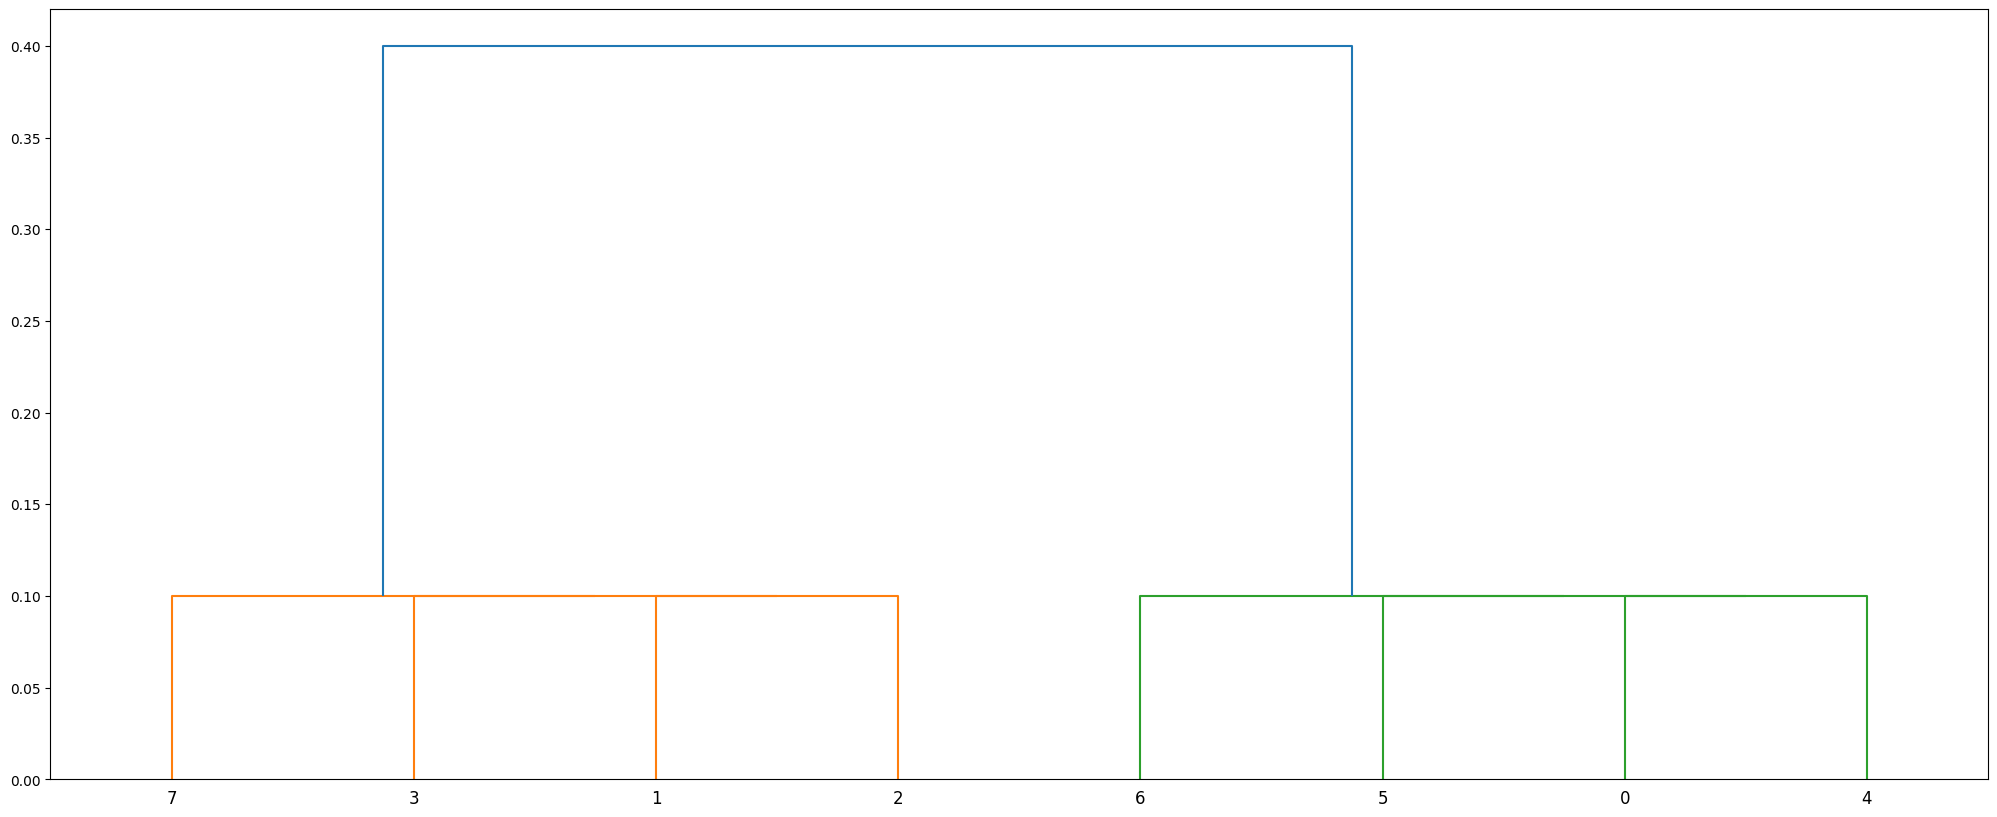

In [7]:
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Y)

In [16]:
from paths import data_prod_path
import pandas as pd
from compare_sigs import step2_plot_standard
import numpy
import h5py
mat_path = data_prod_path+"SM_sketches/sim_matrices/PhageSim_n500_k12.mat"

with open(mat_path, "rb") as f:
    D = numpy.load(f)

print(D)

[[1.    0.008 0.006 0.01  0.006 0.008 0.002 0.006 0.008 0.008 0.008 0.004
  0.006 0.002 0.008 0.    0.012 0.014 0.002 0.004 0.008 0.004 0.006]
 [0.008 1.    0.006 0.002 0.006 0.006 0.002 0.004 0.006 0.006 0.008 0.004
  0.004 0.006 0.01  0.012 0.008 0.006 0.004 0.006 0.006 0.006 0.006]
 [0.006 0.006 1.    0.006 0.004 0.002 0.002 0.004 0.004 0.004 0.01  0.
  0.004 0.008 0.01  0.004 0.002 0.006 0.004 0.002 0.002 0.002 0.004]
 [0.01  0.002 0.006 1.    0.004 0.004 0.    0.002 0.002 0.    0.004 0.006
  0.002 0.002 0.002 0.004 0.018 0.026 0.002 0.002 0.004 0.002 0.002]
 [0.006 0.006 0.004 0.004 1.    0.002 0.002 0.006 0.008 0.008 0.006 0.002
  0.006 0.002 0.004 0.006 0.002 0.004 0.004 0.002 0.006 0.004 0.002]
 [0.008 0.006 0.002 0.004 0.002 1.    0.002 0.002 0.004 0.004 0.006 0.
  0.006 0.006 0.006 0.008 0.002 0.004 0.006 0.002 0.004 0.002 0.002]
 [0.002 0.002 0.002 0.    0.002 0.002 1.    0.002 0.002 0.002 0.004 0.
  0.002 0.002 0.004 0.004 0.    0.002 0.004 0.    0.    0.    0.   ]
 [0.006 

In [18]:
Y = linkage(D, 'single')
print(Y)

[[21.         22.          0.24040799  2.        ]
 [ 7.         12.          0.24224781  2.        ]
 [19.         23.          0.3233945   3.        ]
 [ 8.         24.          0.44976883  3.        ]
 [10.         14.          0.4526323   2.        ]
 [ 9.         26.          0.58539901  4.        ]
 [13.         28.          0.69732345  5.        ]
 [16.         17.          1.10034722  2.        ]
 [27.         29.          1.17701997  7.        ]
 [20.         25.          1.19504142  4.        ]
 [ 3.         30.          1.39251427  3.        ]
 [ 1.         15.          1.39736609  2.        ]
 [11.         34.          1.39743479  3.        ]
 [ 0.         33.          1.40024426  4.        ]
 [35.         36.          1.40302245  7.        ]
 [18.         37.          1.40304668  8.        ]
 [ 5.         38.          1.40307092  9.        ]
 [ 4.         39.          1.40580511 10.        ]
 [ 2.         40.          1.40580795 11.        ]
 [ 6.         41.          1.40

### Check if euclidean distance on row is used

In [21]:
import numpy as np
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

def manual_euclidean_distances(D):
    """
    Compute pairwise Euclidean distances between all rows of D.
    Mirrors what linkage(D, 'single') does internally.
    """
    n = D.shape[0]
    dist_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            diff = D[i] - D[j]
            dist_matrix[i, j] = np.sqrt(np.sum(diff ** 2))
    
    return dist_matrix

# --- Compare ---
manual_dist = manual_euclidean_distances(D)

# linkage() uses the condensed form of this matrix internally
# so we convert our manual result to condensed and re-run linkage
Y_manual  = linkage(squareform(manual_dist), method='single')
Y_linkage = linkage(D, method='single')

print("Match:", np.allclose(Y_manual, Y_linkage))

Match: True


In Euclidean distance, the distance between two genomes is calculated by treating each row of `D` as a **vector of similarity scores** against all other genomes in the dataset.

For two genomes `i` and `j`, you take their respective rows from `D` — each row being a list of ~500 similarity values — and compute how far apart those two vectors are in 500-dimensional space. This is done by taking the difference at each position, squaring it, summing all squared differences, and taking the square root.

In other words, rather than asking *"how similar are genome i and genome j?"* (which would just be a single value read directly from `D`), it asks *"how similarly does genome i relate to all other genomes, compared to how genome j relates to all other genomes?"* Two genomes are considered close if their entire **pattern of similarities** across the dataset is alike.

This is why distances can exceed 1 even though every individual value in `D` is between 0 and 1 — the Euclidean distance accumulates differences across hundreds of dimensions simultaneously, so the total can grow well beyond the scale of any single value.

In [30]:
cutoff = 0.28
bact_val = [cutoff**2] * 23
print(np.sqrt(sum(bact_val)))

1.3428328265275615
